In [2]:
import os
import csv
import ast
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
import colorcet as cc
import matplotlib.colors as mcolors
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from utils import savefig

plt.rcParams['font.size'] = 14

mpl.rcParams['svg.fonttype'] = 'none'


['#ff6700', '#f9cb24', '#63ae0e', '#0068b0']


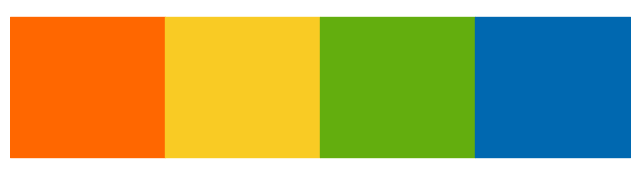

In [3]:
# Get colorcet colors
colors = np.array([cc.cm.rainbow.reversed()(i) for i in np.linspace(0.1, 0.9, 4)])

# Convert to hex format
hex_colors = [mcolors.to_hex(color) for color in colors]
print(hex_colors)


# Plot the colors
plt.figure(figsize=(8, 2))
for i, color in enumerate(hex_colors):
    plt.fill_between([i, i+1], 0, 1, color=color)
plt.xlim(0, len(hex_colors))
plt.xticks([])
plt.yticks([])
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.show()

'#ebcd24', '#a1bc18', '#4da910', '#35876f'
'#147a8e', '#0068b0', '#0051d6', '#0035f9'

In [ ]:
plt.figure(figsize=(4.5, 3.8), dpi=180)

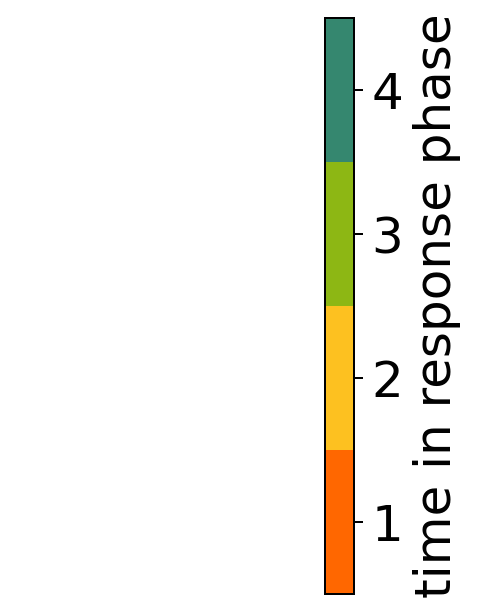

In [5]:
colors = np.array([cc.cm.rainbow.reversed()(i) for i in np.linspace(0.1, 0.8, 4)])
colormap_label = "time in response phase"

plt.figure(figsize=(3, 3.8), dpi=180)
ax = plt.gca()

cmap = ListedColormap(colors)
norm = plt.Normalize(vmin=0.5, vmax=0.5+4)
plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ticks=np.arange(1, 5), label=colormap_label, ax=ax)
plt.xticks([])
plt.yticks([])
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.tight_layout()
savefig("./figures/others", "fig1colorbar", format="svg", close=False)
plt.show()

0.03140159231631414 0.028363665136931778


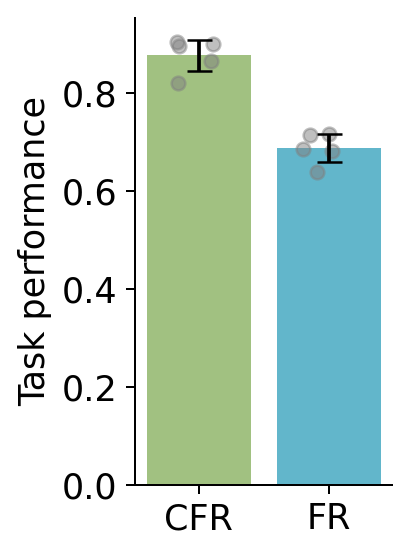

In [ ]:
condfr_perf = np.array([0.448, 0.45175, 0.44975, 0.432, 0.41025]) * 2
fr_perf = np.array([0.7165, 0.713, 0.68475, 0.680125, 0.63775])
condfr_perf_std = np.std(condfr_perf)
fr_perf_std = np.std(fr_perf)
print(condfr_perf_std, fr_perf_std)

plt.figure(figsize=(2.5, 3.3), dpi=180)
plt.bar(0, np.mean(condfr_perf), color="#A1C181", yerr=[condfr_perf_std], capsize=5)
plt.bar(1, np.mean(fr_perf), color="#62B6CB", yerr=[fr_perf_std], capsize=5)
plt.scatter(np.zeros_like(condfr_perf)+np.random.uniform(-0.2, 0.2, size=len(condfr_perf)), condfr_perf, color="grey", alpha=0.5, s=30)
plt.scatter(np.ones_like(fr_perf)+np.random.uniform(-0.2, 0.2, size=len(fr_perf)), fr_perf, color="grey", alpha=0.5, s=30)
plt.xticks([0, 1], ["CFR", "FR"])
# plt.ylabel("Proportion of explained\nvariance of index > 0.4")
plt.ylabel("Task performance")
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
savefig("./figures/fig6", "fig6B", format="svg", close=False)
plt.show()


In [3]:
def load_data(path, model_num):
    data_single_model = {}
    data_single_model["model_num"] = model_num
    # data_single_model["exp"] = exp

    # for key, value in paramters.items():
    #     data_single_model[key] = value

    # data_single_model["accuracy"] = float(row[0])
    # data_single_model["forward_asymmetry"] = float(row[1])
    # data_single_model["temporal_factor"] = float(row[2])

    classifier_data = pickle.load(open(path/"ridge_classifier_stat.pkl", "rb"))
    data_single_model["index_decoding_accuracy_encoding_phase"] = classifier_data["index_enc_acc"]
    data_single_model["item_decoding_accuracy_encoding_phase"] = classifier_data["item_enc_acc"]
    data_single_model["last_item_decoding_accuracy_encoding_phase"] = classifier_data["item_enc_acc_last"]
    data_single_model["index_decoding_accuracy_recall_phase"] = classifier_data["index_rec_acc"]
    data_single_model["item_decoding_accuracy_recall_phase"] = classifier_data["item_rec_acc"]
    data_single_model["last_item_decoding_accuracy_recall_phase"] = classifier_data["item_rec_acc_last"]
    data_single_model["index_decoding_accuracy"] = (data_single_model["index_decoding_accuracy_encoding_phase"] + data_single_model["index_decoding_accuracy_recall_phase"]) / 2
    data_single_model["item_decoding_accuracy"] = (data_single_model["item_decoding_accuracy_encoding_phase"] + data_single_model["item_decoding_accuracy_recall_phase"]) / 2
    data_single_model["last_item_decoding_accuracy"] = (data_single_model["last_item_decoding_accuracy_encoding_phase"] + data_single_model["last_item_decoding_accuracy_recall_phase"]) / 2

    explained_variance_data = np.load(path/"explained_variance.npy")
    data_single_model["explained_variance_encoding_index"] = explained_variance_data[0]
    data_single_model["explained_variance_recall_index"] = explained_variance_data[1]
    data_single_model["explained_variance_index"] = (data_single_model["explained_variance_encoding_index"] + data_single_model["explained_variance_recall_index"]) / 2
    data_single_model["explained_variance_encoding_identity"] = explained_variance_data[2]
    data_single_model["explained_variance_recall_identity"] = explained_variance_data[3]
    data_single_model["explained_variance_identity"] = (data_single_model["explained_variance_encoding_identity"] + data_single_model["explained_variance_recall_identity"]) / 2

    cross_decoding_data = np.load(path/"cross_acc.npy")
    data_single_model["cross_decoding_accuracy_index_rec_enc"] = cross_decoding_data[0]
    data_single_model["cross_decoding_accuracy_identity_rec_enc"] = cross_decoding_data[1]
    data_single_model["cross_decoding_accuracy_index_enc_rec"] = cross_decoding_data[2]
    data_single_model["cross_decoding_accuracy_identity_enc_rec"] = cross_decoding_data[3]
    data_single_model["cross_decoding_accuracy_index"] = (data_single_model["cross_decoding_accuracy_index_rec_enc"] + data_single_model["cross_decoding_accuracy_index_enc_rec"]) / 2
    data_single_model["cross_decoding_accuracy_identity"] = (data_single_model["cross_decoding_accuracy_identity_rec_enc"] + data_single_model["cross_decoding_accuracy_identity_enc_rec"]) / 2

            # try:
            #     training_data = np.load(training_data_path/"accuracy_2.npy")
            # except:
            #     training_data = np.load(training_data_path/"accuracy_1.npy")
            # # find the final consecutive zeros in the training data and set it to the last non-zero value
            # zero_indices = np.where(training_data == 0)[0]
            # if len(zero_indices) > 0:
            #     last_zero_index = zero_indices[0]
            #     training_data[last_zero_index:] = training_data[last_zero_index-1]
            # if training_data.shape[0] < training_data_length and training_data.shape[0] > 0:
            #     training_data = np.pad(training_data, (0, training_data_length - training_data.shape[0]), mode='constant', constant_values=training_data[-1])
            # data_single_model["training_accuracy"] = training_data
    return data_single_model


In [4]:
data_condfr = []

data_folder = Path("./experiments/CondFR/figures/free_recall/ValueMemoryGRU")
# training_curve_folder = Path("./experiments/CondFR/saved_models/free_recall/ValueMemoryGRU")
# perturbation_folder = Path("./experiments/CondFR/figures/perturbation/free_recall/ValueMemoryGRU")
# item_invariance_folder = Path("./experiments/CondFR/figures/item_invariant/free_recall/ValueMemoryGRU")
seq_len = 8

# setups = ["setup_condfr_fixone_noise", "setup_condfr_fixone_noise2", "setup_condfr_fixone_noise3"]
setups = ["setup_condfr_fixone_noise2"]

for setup in setups:
    for i in range(5):
        data_path = data_folder / setup / str(i)
        # training_data_path = training_curve_folder / (setup + "-" + str(i))
        if os.path.exists(data_path/"cross_acc.npy"):
            data_single_model = load_data(data_path, i)
            if data_single_model:
                data_single_model["pretrained"] = False
                # perturbation_data = np.load(perturbation_folder / setup_name / str(i) / "perturbation_accuracies.npy")
                # data_single_model["perturbation_accuracy"] = perturbation_data
                # if os.path.exists(item_invariance_folder / setup / str(i) / "decoding_accuracy.npy"):
                #     item_invariance_data = np.load(item_invariance_folder / setup / str(i) / "decoding_accuracy.npy")
                #     data_single_model["item_invariance_accuracy"] = item_invariance_data
                # else:
                #     data_single_model["item_invariance_accuracy"] = None
                # data_reservoir.append(data_single_model)
                data_condfr.append(data_single_model)

df_condfr = pd.DataFrame(data_condfr)
print(len(df_condfr))

5


0.021782260737627335 0.008976602421824879
0.1801548422164665 0.005329941152109124


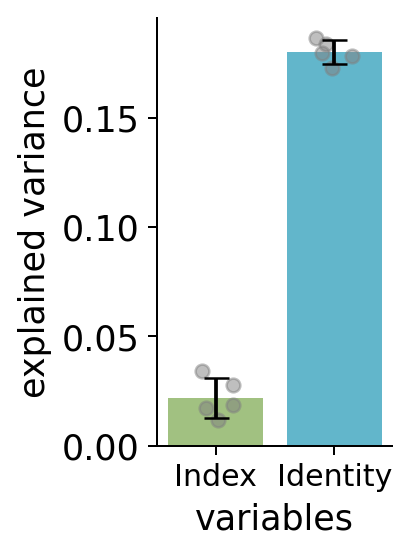

In [6]:
explained_variance_index_mean = df_condfr["explained_variance_index"].mean()
explained_variance_index_std = df_condfr["explained_variance_index"].std()
print(explained_variance_index_mean, explained_variance_index_std)

explained_variance_identity_mean = df_condfr["explained_variance_identity"].mean()
explained_variance_identity_std = df_condfr["explained_variance_identity"].std()
print(explained_variance_identity_mean, explained_variance_identity_std)

explained_variance_index_data = df_condfr["explained_variance_index"].values
explained_variance_identity_data = df_condfr["explained_variance_identity"].values


# Create a bar plot for the explained variance data
labels = ['Index', 'Identity']
means = [explained_variance_index_mean, explained_variance_identity_mean]
stds = [explained_variance_index_std, explained_variance_identity_std]

x = range(len(labels))

fig = plt.figure(figsize=(2.5, 3.3), dpi=180)
ax = plt.gca()
plt.bar(x, means, 0.8, yerr=stds, align='center', color=["#A1C181", "#62B6CB"], capsize=5)
plt.scatter(np.zeros_like(explained_variance_index_data)+np.random.uniform(-0.2, 0.2, size=len(explained_variance_index_data)), explained_variance_index_data, color="grey", alpha=0.5, s=30)
plt.scatter(np.ones_like(explained_variance_identity_data)+np.random.uniform(-0.2, 0.2, size=len(explained_variance_identity_data)), explained_variance_identity_data, color="grey", alpha=0.5, s=30)
# for i in range(len(df_condfr)):
#     plt.plot([0, 1], [df_condfr["explained_variance_index"].iloc[i], df_condfr["explained_variance_identity"].iloc[i]], color='grey', linestyle='-', linewidth=0.3, alpha=0.7)
plt.ylabel('explained variance')
plt.xlabel('variables')
ax.set_xticks([0,1])
ax.set_xticklabels(labels, fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
savefig("./figures/fig6", "fig6E", format="svg", close=False)
plt.show()



0.13083925221464757 0.01663018332212946
0.394936487906159 0.05990558829522765


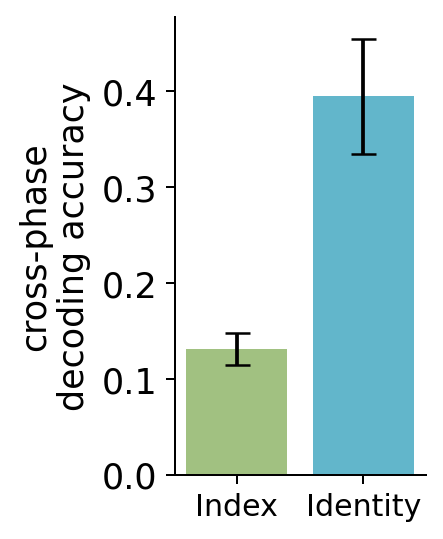

In [25]:
cross_decoding_accuracy_index_mean = df_condfr["cross_decoding_accuracy_index"].mean()
cross_decoding_accuracy_index_std = df_condfr["cross_decoding_accuracy_index"].std()
print(cross_decoding_accuracy_index_mean, cross_decoding_accuracy_index_std)

cross_decoding_accuracy_identity_mean = df_condfr["cross_decoding_accuracy_identity"].mean()
cross_decoding_accuracy_identity_std = df_condfr["cross_decoding_accuracy_identity"].std()
print(cross_decoding_accuracy_identity_mean, cross_decoding_accuracy_identity_std)


# Create a bar plot for the explained variance data
labels = ['Index', 'Identity']
means = [cross_decoding_accuracy_index_mean, cross_decoding_accuracy_identity_mean]
stds = [cross_decoding_accuracy_index_std, cross_decoding_accuracy_identity_std]

x = range(len(labels))

fig = plt.figure(figsize=(1.8, 3.3), dpi=180)
ax = plt.gca()
plt.bar(x, means, 0.8, yerr=stds, align='center', color=["#A1C181", "#62B6CB"], capsize=5)
plt.ylabel('cross-phase\ndecoding accuracy')
ax.set_xticks([0,1])
ax.set_xticklabels(labels, fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()



### key-value memory model

In [18]:
data_folder = Path("/scratch/ml8736/memory-replay/Transform/figures/ValueMemoryGRU/setup_kv_sametransform")

keys_index_variance, keys_identity_variance, values_index_variance, values_identity_variance = [], [], [], []

for i in range(20):
    try:
        with open(data_folder / str(i) / "contiguity_effect.csv", "r") as f:
            reader = csv.reader(f)
            for row in reader:
                accuracy = float(row[0])
                break
        # print(accuracy)
    except:
        continue
    if accuracy < 0.5:
        continue
    try:
        data = np.load(data_folder / str(i) / "explained_variance.npy")
        if data[0] < 0.5:
            continue
        keys_index_variance.append(data[0])
        keys_identity_variance.append(data[1])
        values_index_variance.append(data[2])
        values_identity_variance.append(data[3])
    except:
        pass

keys_index_variance = np.array(keys_index_variance)
keys_identity_variance = np.array(keys_identity_variance)
values_index_variance = np.array(values_index_variance)
values_identity_variance = np.array(values_identity_variance)

print(keys_index_variance)
print(keys_identity_variance)
print(values_index_variance)
print(values_identity_variance)


[0.89732859 0.90567231 0.91933891 0.91283159 0.82023462 0.94185696
 0.91488593 0.82137319 0.94033333 0.89115258 0.92721805 0.90617947
 0.88607521 0.89455369]
[0.02832457 0.02142544 0.02232681 0.02321638 0.0327451  0.0199569
 0.02848358 0.02380868 0.01985865 0.01843906 0.02428169 0.01819332
 0.02920381 0.02752023]
[0.30991793 0.47785048 0.38303009 0.42124982 0.40046109 0.26737998
 0.45248791 0.30362104 0.34222716 0.46068072 0.5432581  0.28000717
 0.38586582 0.47812542]
[0.13538704 0.23124204 0.22403927 0.18125466 0.11426589 0.07069357
 0.14609514 0.08724176 0.14047312 0.12600642 0.08639407 0.07757117
 0.15631825 0.24168741]


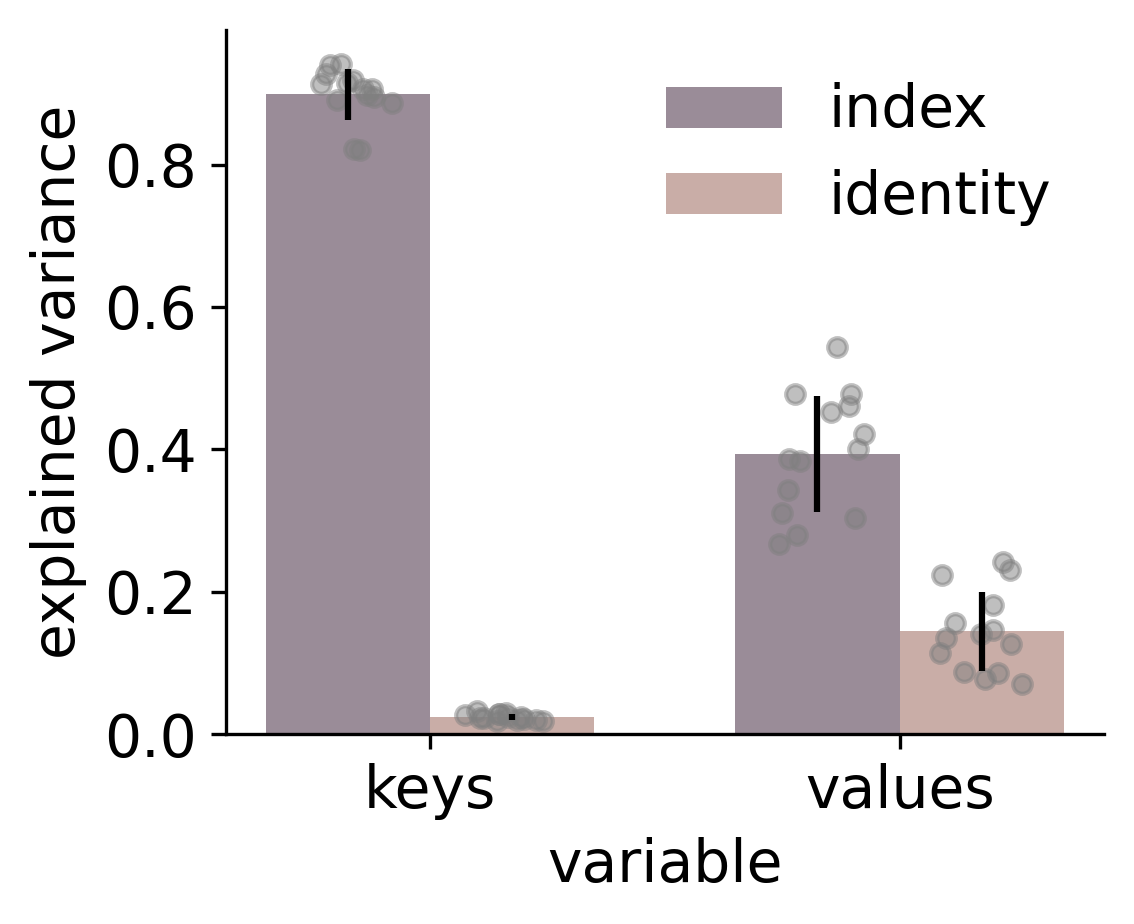

In [ ]:
plt.figure(figsize=(4, 3.3), dpi=300)
bar_width = 0.35
index = np.arange(2)
plt.bar(index, [np.mean(keys_index_variance), np.mean(values_index_variance)], bar_width, label="index", color=["#9A8C98"],
    yerr=[np.std(keys_index_variance), np.std(values_index_variance)])
plt.bar(index + bar_width, [np.mean(keys_identity_variance), np.mean(values_identity_variance)], bar_width, label="identity", color=["#C9ADA7"],
    yerr=[np.std(keys_identity_variance), np.std(values_identity_variance)])
plt.scatter(np.ones_like(keys_index_variance)*0+np.random.uniform(-0.1, 0.1, size=len(keys_index_variance)), keys_index_variance, color="grey", alpha=0.5, s=20)
plt.scatter(np.ones_like(keys_identity_variance)*bar_width+np.random.uniform(-0.1, 0.1, size=len(keys_identity_variance   )), keys_identity_variance, color="grey", alpha=0.5, s=20)
plt.scatter(np.ones_like(values_index_variance)+np.random.uniform(-0.1, 0.1, size=len(values_index_variance)), values_index_variance, color="grey", alpha=0.5, s=20)
plt.scatter(np.ones_like(values_identity_variance)*(1+bar_width)+np.random.uniform(-0.1, 0.1, size=len(values_identity_variance)), values_identity_variance, color="grey", alpha=0.5, s=20)
plt.xlabel("variable")
plt.ylabel("explained variance")
plt.xticks(index + bar_width / 2, ["keys", "values"])
plt.legend(frameon=False)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
savefig("./figures/exfig1", "exfig1C", format="svg", close=False)
plt.show()


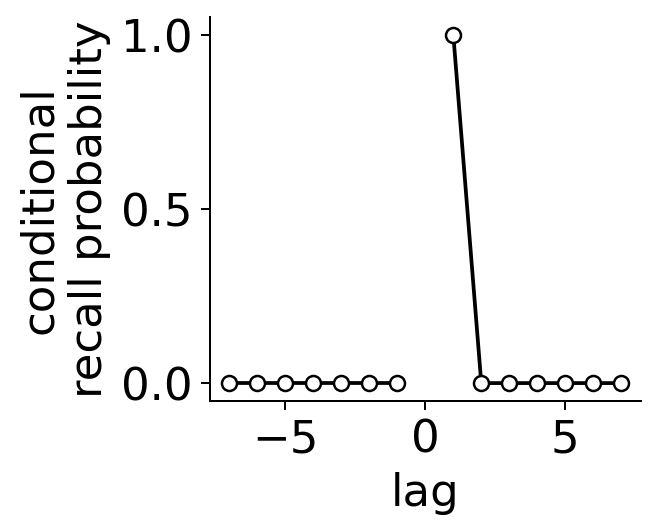

In [20]:
plt.rcParams['font.size'] = 18

memory_num = 8
results_all_time = np.zeros(memory_num*2-1)
results_all_time[memory_num] = 1

plt.figure(figsize=(4, 3.3), dpi=180)
plt.scatter(np.arange(-memory_num+1, 0), results_all_time[:memory_num-1], c='w', edgecolor='k', zorder=2)
plt.plot(np.arange(-memory_num+1, 0), results_all_time[:memory_num-1], c='k', zorder=1)
plt.scatter(np.arange(1, memory_num), results_all_time[memory_num:], c='w', edgecolor='k', zorder=2)
plt.plot(np.arange(1, memory_num), results_all_time[memory_num:], c='k', zorder=1)
plt.xlabel("lag")
plt.ylabel("conditional\nrecall probability")
# title = title if title else "conditional recall probability"
# plt.title(title)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.yticks([0, 0.5, 1])

plt.tight_layout()
# savefig(save_path, save_name, format=format)
savefig("./figures/fig1", "fig1G", format="svg", close=False)
plt.show()

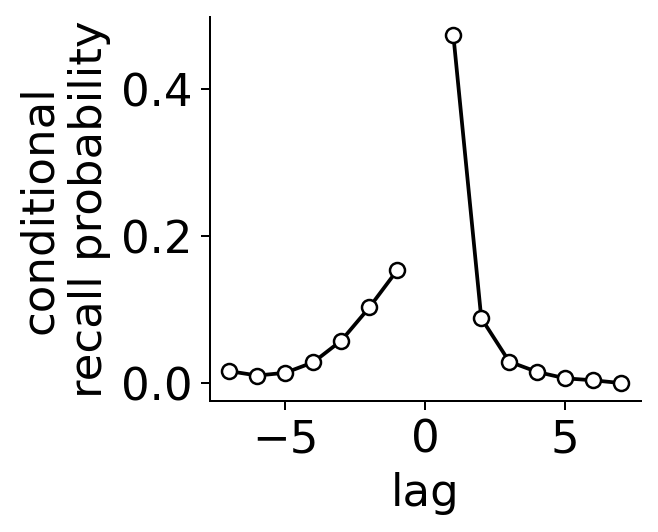

In [3]:
plt.rcParams['font.size'] = 18

memory_num = 8
# results_all_time = np.zeros(memory_num*2-1)
# results_all_time[memory_num] = 1
results_all_time = np.array([0.016185927492183227,0.010251087411716042,0.014027803826558796,0.028325373111320645,0.05783771423873473,0.1028705613947645,0.15368923533053977,0.0,0.4740164479853659,0.0883032266517996,0.029134669485929805,0.015106865659371011,0.006474370996873291,0.003776716414842753,0.0])

plt.figure(figsize=(4, 3.3), dpi=180)
plt.scatter(np.arange(-memory_num+1, 0), results_all_time[:memory_num-1], c='w', edgecolor='k', zorder=2)
plt.plot(np.arange(-memory_num+1, 0), results_all_time[:memory_num-1], c='k', zorder=1)
plt.scatter(np.arange(1, memory_num), results_all_time[memory_num:], c='w', edgecolor='k', zorder=2)
plt.plot(np.arange(1, memory_num), results_all_time[memory_num:], c='k', zorder=1)
plt.xlabel("lag")
plt.ylabel("conditional\nrecall probability")
# title = title if title else "conditional recall probability"
# plt.title(title)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# plt.yticks([0, 0.5, 1])

plt.tight_layout()
# savefig(save_path, save_name, format=format)
savefig("./figures/fig1", "fig1D", format="svg", close=False)
plt.show()

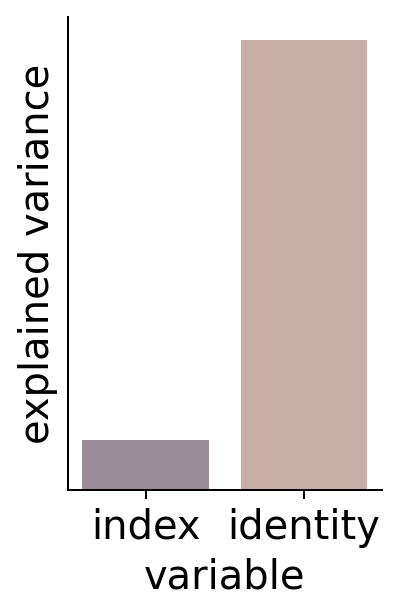

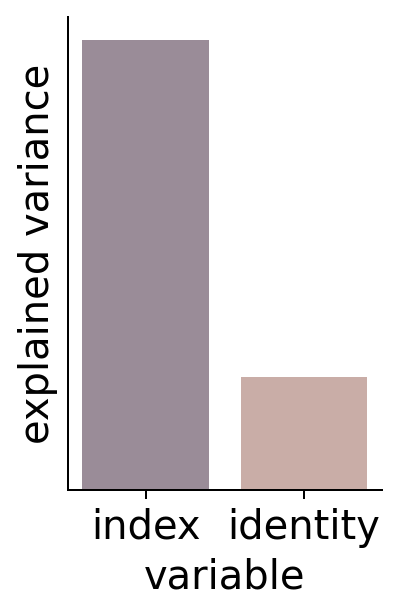

In [23]:
plt.rcParams['font.size'] = 16

plt.figure(figsize=(2.5, 3.7), dpi=180)
plt.bar(["index", "identity"], [0.1, 0.9], color=["#9A8C98", "#C9ADA7"])
plt.xlabel("variable")
plt.ylabel("explained variance")
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_yticks([])
plt.tight_layout()
savefig("./figures/fig1", "fig1F", format="svg", close=False)
plt.show()

plt.figure(figsize=(2.5, 3.7), dpi=180)
plt.bar(["index", "identity"], [0.8, 0.2], color=["#9A8C98", "#C9ADA7"])
plt.xlabel("variable")
plt.ylabel("explained variance")
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_yticks([])
plt.tight_layout()
savefig("./figures/fig1", "fig1I", format="svg", close=False)
plt.show()